In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from astropy import units as u
from astropy.coordinates import SkyCoord

In [62]:
# SS_LCs = pd.read_csv("https://cdsarc.cds.unistra.fr/ftp/J/AJ/155/201/table8.dat", sep = "\\s+|\\||\\|s",
#                      names = ["Name","MJD","Phase","Filter","Mag","Mag Error","Flux","Flux Error"])
SS_LCs = pd.read_fwf("https://cdsarc.cds.unistra.fr/ftp/J/AJ/155/201/table8.dat",
                     names = ["Name","MJD","Phase","Filter","Mag","Mag Error","Flux","Flux Error"],
                    colspecs = [[0,23],[24,35],[37,45],[46,52],[53,61],[62,69],[71,81],[83,92]])
SS_LCs

,Name,MJD,Phase,Filter,Mag,Mag Error,Flux,Flux Error
0,CSS121009:011101-172841,56234.27359,14.27359,WHIRCJ,18.97756,0.05157,256.4340,12.1698
1,CSS121009:011101-172841,56229.31361,9.31361,WHIRCH,18.64361,0.04781,348.7850,15.3479
2,CSS121009:011101-172841,56229.28541,9.28541,WHIRCJ,19.27324,0.07101,195.3014,12.7551
3,CSS121009:011101-172841,56234.22657,14.22657,WHIRCH,18.53778,0.04162,384.4939,14.7330
4,CSS121114:090202+101800,56254.50847,2.50847,WHIRCH,18.08766,0.02963,582.0156,15.8819
...,...,...,...,...,...,...,...,...
181,iPTF13ebh,56640.15049,21.15049,WHIRCJ,16.22341,0.01276,3240.6910,38.0783
182,iPTF13ebh,56617.15312,-1.84688,WHIRCK,15.39068,0.01739,6977.9267,111.7250
183,iPTF13ebh,56636.16017,17.16017,WHIRCK,15.48230,0.07114,6413.2790,419.6413
184,iPTF13ebh,56640.15936,21.15936,WHIRCK,15.45387,0.01509,6583.4459,91.4833


In [63]:
SS_LCs["Mag"].dtype

dtype('float64')

In [64]:
SS_info = pd.read_fwf("https://cdsarc.cds.unistra.fr/ftp/J/AJ/155/201/table3.dat", 
                      names = ["Name","RA","Dec","SN Type","z","Classifier","Discoverer","Tmax","Has LC?"],
                      colspecs = [[0,23],[24,36],[37,49],[50,52],[54,61],[63,74],[75,81],[81,86],[87,90]]                                                                      )
SS_info

,Name,RA,Dec,SN Type,z,Classifier,Discoverer,Tmax,Has LC?
0,CSS121006:232854+085452,23 28 54.48,+08 54 51.6,Ia,0.0800,D12b,D12c,56207,Yes
1,CSS121009:011101-172841,01 11 01.091,-17 28 42.28,Ia,0.0600,D12b,D12c,56220,Yes
2,CSS121114:090202+101800,09 02 02.420,+10 18 00.31,Ia,0.0420,G12,D12a,56252,Yes
3,CSS130218:092354+385837,09 23 54.52,+38 58 36.8,Ia,0.0500,D13b,D13a,56361,No
4,CSS130317:082848+293031,08 28 47.784,+29 30 30.85,Ia,0.0800,D13b,D13b,56370,No
...,...,...,...,...,...,...,...,...,...
69,iPTF13dge,05 03 35.091,+01 34 17.03,Ia,0.0158,C13b,C13b,56555,No
70,iPTF13dkj,23 08 50.737,+20 04 08.59,Ia,0.0300,C13a,C13a,56555,No
71,iPTF13dkl,23 44 57.999,+03 23 40.07,Ia,0.0400,C13a,C13a,56556,Yes
72,iPTF13dkx,01 20 53.115,+03 20 23.65,Ia,0.0300,C13a,C13a,56561,Yes


In [65]:
c1 =SS_info[SS_info["Name"]=="SN 2011fs"]["RA"]
c2 = SS_info[SS_info["Name"]=="SN 2011fs"]["Dec"]

In [66]:
c = SkyCoord(c1,c2,unit=(u.hourangle, u.deg))

In [67]:
c.ra.deg[0]

np.float64(334.3312875)

In [68]:
RA_degs = []
Dec_degs = []
for i in range(len(SS_info["Name"])):
    c1 = SS_info["RA"][i]
    c2 = SS_info["Dec"][i]
    c = SkyCoord(c1,c2,unit=(u.hourangle, u.deg))
    RA_degs.append(c.ra.deg)
    Dec_degs.append(c.dec.deg)
SS_info["RA_deg"] = RA_degs
SS_info["Dec_deg"] = Dec_degs

In [69]:
#SS_info = SS_info[SS_info["Has LC?"] == "Yes"]

In [70]:
SS_info = SS_info.reset_index(drop = True)

In [71]:
SS_info

,Name,RA,Dec,SN Type,z,Classifier,Discoverer,Tmax,Has LC?,RA_deg,Dec_deg
0,CSS121006:232854+085452,23 28 54.48,+08 54 51.6,Ia,0.0800,D12b,D12c,56207,Yes,352.227000,8.914333
1,CSS121009:011101-172841,01 11 01.091,-17 28 42.28,Ia,0.0600,D12b,D12c,56220,Yes,17.754546,-17.478411
2,CSS121114:090202+101800,09 02 02.420,+10 18 00.31,Ia,0.0420,G12,D12a,56252,Yes,135.510083,10.300086
3,CSS130218:092354+385837,09 23 54.52,+38 58 36.8,Ia,0.0500,D13b,D13a,56361,No,140.977167,38.976889
4,CSS130317:082848+293031,08 28 47.784,+29 30 30.85,Ia,0.0800,D13b,D13b,56370,No,127.199100,29.508569
...,...,...,...,...,...,...,...,...,...,...,...
69,iPTF13dge,05 03 35.091,+01 34 17.03,Ia,0.0158,C13b,C13b,56555,No,75.896212,1.571397
70,iPTF13dkj,23 08 50.737,+20 04 08.59,Ia,0.0300,C13a,C13a,56555,No,347.211404,20.069053
71,iPTF13dkl,23 44 57.999,+03 23 40.07,Ia,0.0400,C13a,C13a,56556,Yes,356.241662,3.394464
72,iPTF13dkx,01 20 53.115,+03 20 23.65,Ia,0.0300,C13a,C13a,56561,Yes,20.221312,3.339903


In [72]:
SS_info["Name"] = SS_info["Name"].str.replace(" ","")

In [73]:
SS_info["Name"]

0     CSS121006:232854+085452
1     CSS121009:011101-172841
2     CSS121114:090202+101800
3     CSS130218:092354+385837
4     CSS130317:082848+293031
               ...           
69                  iPTF13dge
70                  iPTF13dkj
71                  iPTF13dkl
72                  iPTF13dkx
73                  iPTF13ebh
Name: Name, Length: 74, dtype: str

In [130]:
names = []
RAs = []
Decs = []
zs = []
LCs = []
for i, name in enumerate(SS_info["Name"]):
    if (((SS_LCs["Name"] == name).any()) == True) & (name != "PS1-13dkh"): #PS1-13dkh is not a SN Ia
        names.append(name)
        RAs.append(SS_info["RA_deg"][i])
        Decs.append(SS_info["Dec_deg"][i])
        zs.append(SS_info["z"][i])
        LC0s = []
        print(i)
        for band in np.unique(SS_LCs[SS_LCs["Name"]== name]["Filter"]):
            # print(band)
            LC_holder = []
            LC0 = []
            mags = []
            mag_errs = []
            mjd = []
            filtered = SS_LCs.loc[(SS_LCs["Name"]== name) & (SS_LCs["Filter"]== band)]
            #print(filtered.shape)
            # if filtered.shape[0] == 0:
            #     continue
            #print(filtered["Mag"].index[0])
            for mag in filtered["Mag"]:
                # print(mag)
                mags.append(mag)
            for magerr in filtered["Mag Error"]:
                mag_errs.append(magerr)
            for date in filtered["MJD"]:
                mjd.append(date)
            LC_holder.append(mjd)
            LC_holder.append(mags)
            LC_holder.append(mag_errs)
            #print(LC_holder)
            LC0.append(band.replace("WHIRC",""))
            LC0.append(LC_holder)
            LC0s.append(LC0)
        LCs.append(LC0s)
# del LCs[0]
# del names[0]
# del RAs[0]
# del Decs[0]
# del zs[0]

1
2
5
6
9
11
15
18
24
26
27
28
29
30
37
39
40
41
43
44
46
49
51
54
58
59
62
65
69
71
72
73


In [131]:
print(len(LCs))
#print(LCs[:])

32


In [132]:
print(LCs[10][0][1][2])
print(names[6])

[0.08013, 0.05608, 0.09158]
PTF11moy


[0.04854, 0.04236, 0.0548]
[0.64982, 0.64941]


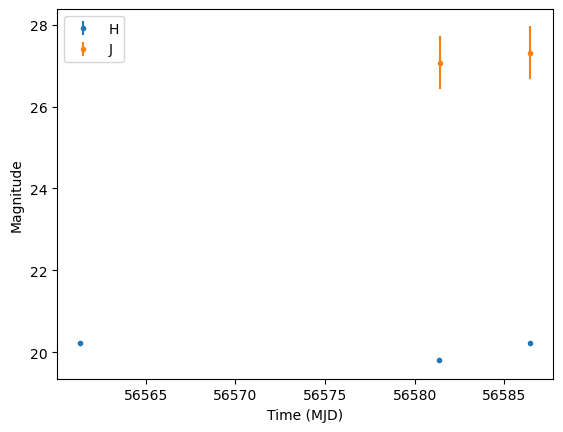

In [133]:
#Plot specific SN
SN_name = "PTF13dad"
plt.figure()
for i in range(len(LCs)):
    if names[i] == SN_name:
        for j in range(len(LCs[i])): #this is a for loop over the bands
            band = LCs[i][j][0]
            mjd = LCs[i][j][1][0]
            mag = LCs[i][j][1][1]
            mag_err = LCs[i][j][1][2]
            print(mag_err)
            plt.errorbar(mjd, mag, yerr = mag_err, label = band, fmt = ".")
plt.xlabel("Time (MJD)")
plt.ylabel("Magnitude")
plt.legend()

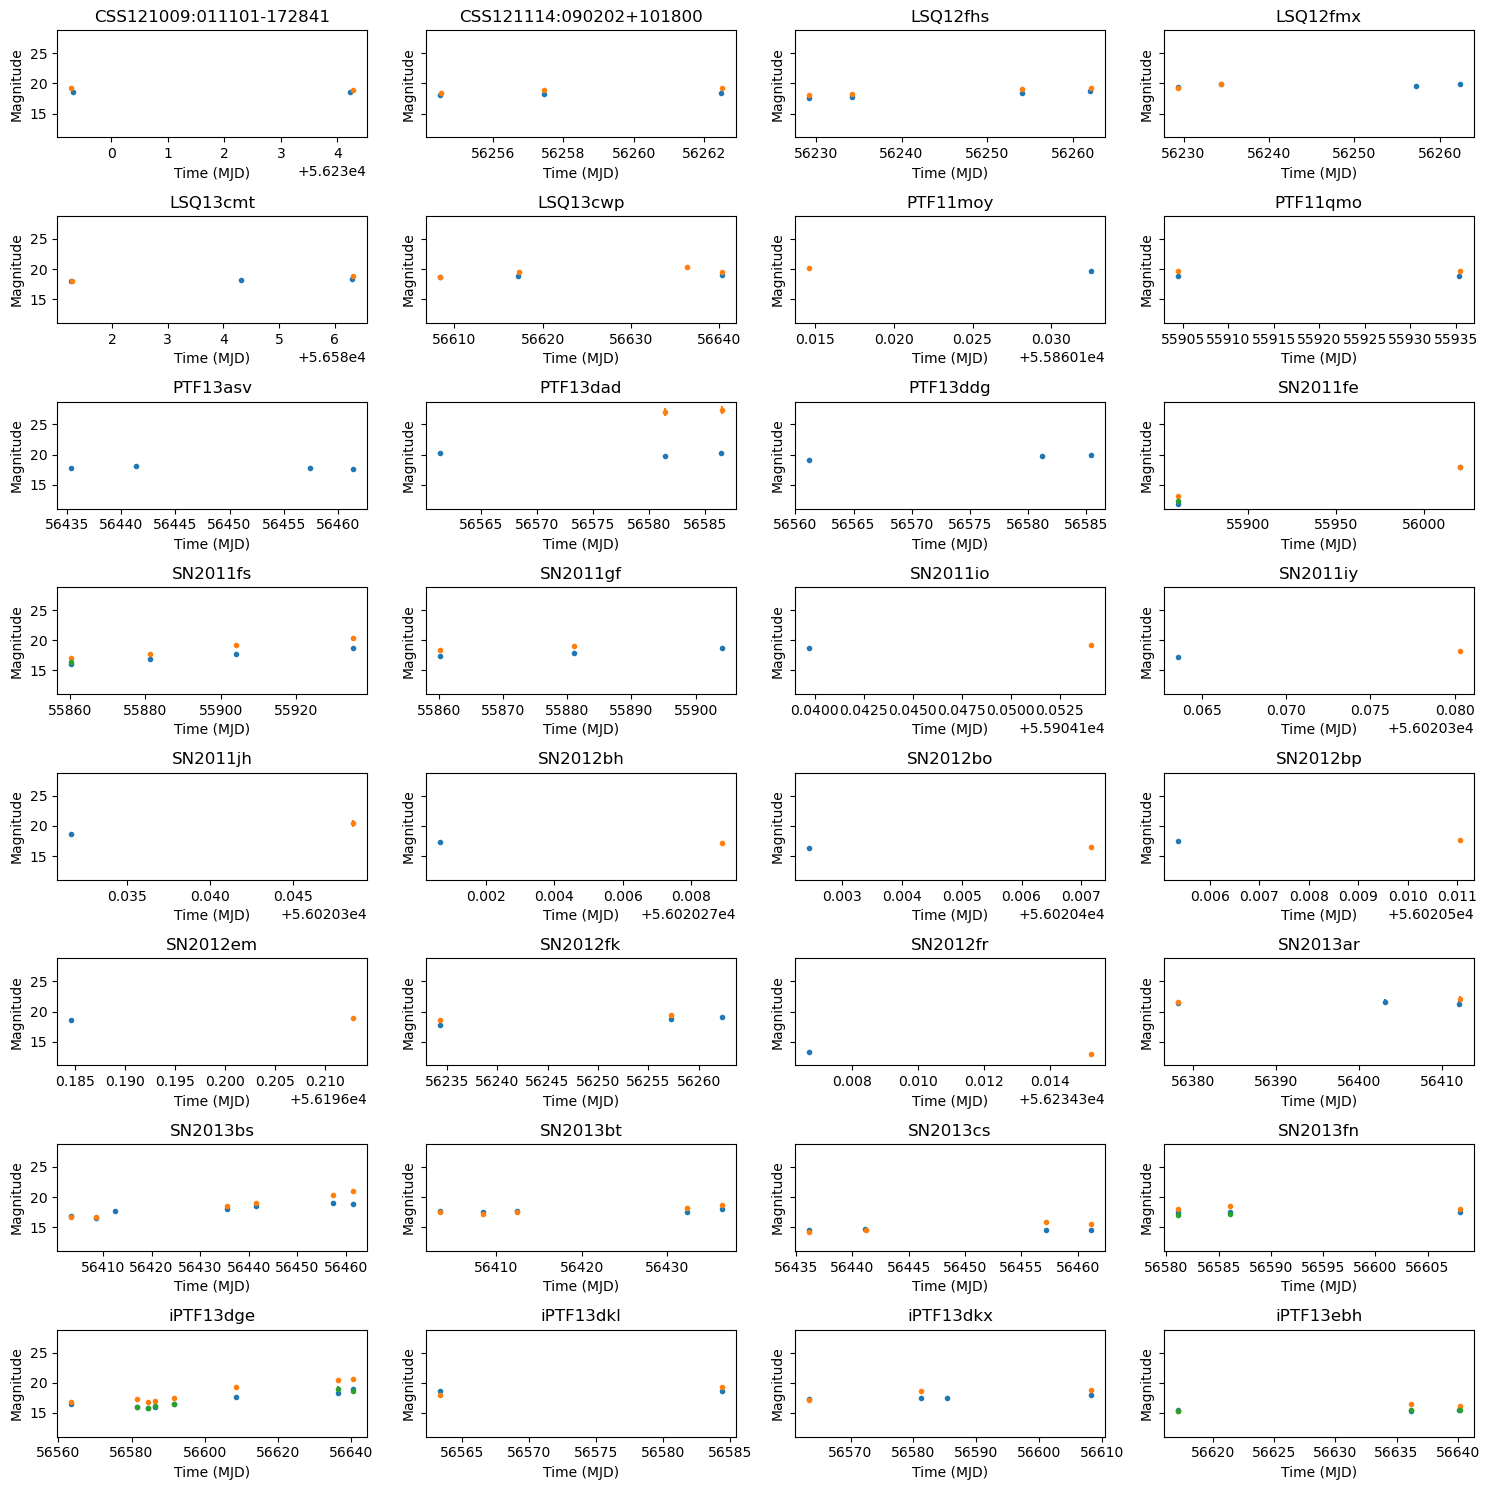

In [158]:
fig, axs = plt.subplots(8,4, sharey=True,figsize = (15,15),layout = "tight")
for i in range(len(LCs)):
    row = int(i/4)
    col = i%4
    for j in range(len(LCs[i])): #this is a for loop over the bands
        band = LCs[i][j][0]
        mjd = LCs[i][j][1][0]
        mag = LCs[i][j][1][1]
        mag_err = LCs[i][j][1][2]
        #print(mag_err)
        axs[row][col].errorbar(mjd, mag, yerr = mag_err, label = band, fmt = ".")
    axs[row][col].set_xlabel("Time (MJD)")
    axs[row][col].set_ylabel("Magnitude")
    #axs[row][col].legend()
    axs[row][col].set_title(names[i])
    axs[row][col].invert_yaxis()
